In [2]:
%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 2.1 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.3 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.3 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/9.3 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.3 MB 2.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 3.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.3 MB 3.3 MB/s eta 0:00:02
   ----------------------------- ---------- 6.8/9.3 MB 3.5 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 3.7 MB/s eta 0:00:01
   -----------------------------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("nfip_claims_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (2000, 31)


,claim_ref,source_system,dateOfLoss,yearOfLoss,state,reportedZipCode,countyCode,latitude,longitude,floodEvent,...,buildingDamageAmount,contentsDamageAmount,waterDepth,floodWaterDuration,amountPaidOnBuildingClaim,amountPaidOnContentsClaim,netBuildingPaymentAmount,nonPaymentReasonBuilding,openDate,mostRecentPaymentDate
0,CLM-6119947,core,2018-04-13 00:00:00+00:00,2018,HI,96734,15003.0,21.4,-157.7,NaN,...,15092.0,NaN,NaN,0.0,13841.58,0.0,13841.58,NaN,2018-04-26 00:00:00+00:00,2018-05-21 00:00:00+00:00
1,CLM-5642877,core,2021-09-01 00:00:00+00:00,2021,MA,1906,25009.0,42.4,-71.0,Hurricane Ida,...,0.0,0.0,NaN,NaN,0.00,0.0,0.00,6.0,2021-09-02 00:00:00+00:00,2021-09-22 00:00:00+00:00
2,CLM-7518535,core,2020-05-20 00:00:00+00:00,2020,MI,48640,26111.0,43.6,-84.3,NaN,...,44478.0,NaN,2.0,NaN,5000.00,0.0,5000.00,NaN,2020-05-20 00:00:00+00:00,2020-06-18 00:00:00+00:00
3,CLM-6796433,core,2024-09-26 00:00:00+00:00,2024,FL,33634,12057.0,28.0,-82.6,Hurricane Helene,...,100212.0,NaN,1.0,NaN,90211.66,0.0,90211.66,NaN,2024-09-30 00:00:00+00:00,2024-12-04 00:00:00+00:00
4,CLM-5558178,core,2024-09-26 00:00:00+00:00,2024,FL,33710,12103.0,27.8,-82.8,Hurricane Helene,...,153834.0,NaN,2.0,NaN,143833.51,0.0,143833.51,NaN,2024-09-28 00:00:00+00:00,2025-02-23 00:00:00+00:00


In [2]:
date_cols = [
    "dateOfLoss",
    "originalConstructionDate",
    "openDate",
    "mostRecentPaymentDate"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   claim_ref                           2000 non-null   str                
 1   source_system                       2000 non-null   str                
 2   dateOfLoss                          2000 non-null   datetime64[us, UTC]
 3   yearOfLoss                          2000 non-null   int64              
 4   state                               2000 non-null   str                
 5   reportedZipCode                     2000 non-null   str                
 6   countyCode                          1991 non-null   float64            
 7   latitude                            1983 non-null   float64            
 8   longitude                           1986 non-null   float64            
 9   floodEvent                          1449 non-null   

In [4]:
print((df["longitude"] < -90).any())

True


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
claim_ref,2000,2000,CLM-6119947,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_system,2000,2,core,1880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dateOfLoss,2000,NaN,NaN,NaN,2022-04-21 17:21:50.400000+00:00,2018-01-04 00:00:00+00:00,2020-08-03 00:00:00+00:00,2022-09-28 00:00:00+00:00,2024-09-26 00:00:00+00:00,2026-08-20 00:00:00+00:00,NaN
yearOfLoss,2000.0,NaN,NaN,NaN,2021.693,2018.0,2020.0,2022.0,2024.0,2026.0,2.239924
state,2000,47,FL,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reportedZipCode,2000,1047,33908,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countyCode,1991.0,NaN,NaN,NaN,23723.138122,1003.0,12071.0,20143.0,37013.0,72061.0,14266.306426
latitude,1983.0,NaN,NaN,NaN,31.818709,-82.6,27.7,30.0,36.45,49.0,8.06067
longitude,1986.0,NaN,NaN,NaN,-84.57578,-159.5,-90.0,-82.6,-80.7,41.6,12.24811
floodEvent,1449,62,Hurricane Helene,295,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate claim_ref:", df["claim_ref"].duplicated().sum())

Rows: 2000
Columns: 31
Duplicate rows: 0
Duplicate claim_ref: 0


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_cols

['yearOfLoss',
 'countyCode',
 'latitude',
 'longitude',
 'occupancyType',
 'numberOfFloorsInTheInsuredBuilding',
 'elevatedBuildingIndicator',
 'primaryResidenceIndicator',
 'totalBuildingInsuranceCoverage',
 'totalContentsInsuranceCoverage',
 'buildingPropertyValue',
 'buildingReplacementCost',
 'buildingDamageAmount',
 'contentsDamageAmount',
 'waterDepth',
 'floodWaterDuration',
 'amountPaidOnBuildingClaim',
 'amountPaidOnContentsClaim',
 'netBuildingPaymentAmount',
 'nonPaymentReasonBuilding']

In [8]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
yearOfLoss,2000.0,2021.693000,2.239924e+00,2018.0,2020.0000,2022.000,2024.0000,2.026000e+03
countyCode,1991.0,23723.138122,1.426631e+04,1003.0,12071.0000,20143.000,37013.0000,7.206100e+04
latitude,1983.0,31.818709,8.060670e+00,-82.6,27.7000,30.000,36.4500,4.900000e+01
longitude,1986.0,-84.575780,1.224811e+01,-159.5,-90.0000,-82.600,-80.7000,4.160000e+01
occupancyType,2000.0,10.071000,4.459361e+00,1.0,11.0000,11.000,11.0000,1.800000e+01
numberOfFloorsInTheInsuredBuilding,1990.0,1.549749,8.055161e-01,1.0,1.0000,1.000,2.0000,5.000000e+00
elevatedBuildingIndicator,2000.0,0.229000,4.202943e-01,0.0,0.0000,0.000,0.0000,1.000000e+00
primaryResidenceIndicator,2000.0,0.677000,4.677397e-01,0.0,0.0000,1.000,1.0000,1.000000e+00
totalBuildingInsuranceCoverage,2000.0,327201.550000,1.020209e+06,5000.0,170525.0000,250000.000,250000.0000,2.016500e+07
totalContentsInsuranceCoverage,2000.0,50896.400000,6.086776e+04,0.0,0.0000,40000.000,100000.0000,5.000000e+05


In [9]:
numeric_summary = pd.DataFrame({
    "min": df[numeric_cols].min(),
    "median": df[numeric_cols].median(),
    "mean": df[numeric_cols].mean(),
    "max": df[numeric_cols].max(),
    "std": df[numeric_cols].std(),
    "skewness": df[numeric_cols].skew(),
    "missing_pct": df[numeric_cols].isna().mean() * 100,
    "zero_pct": (df[numeric_cols] == 0).mean() * 100
}).sort_values("skewness", ascending=False)

numeric_summary

,min,median,mean,max,std,skewness,missing_pct,zero_pct
amountPaidOnBuildingClaim,0.0,23162.115,84081.385552,3.491222e+07,8.357453e+05,40.165812,9.50,10.95
floodWaterDuration,0.0,0.000,0.496437,1.950000e+02,9.504791e+00,20.500837,78.95,20.50
buildingPropertyValue,100.0,206330.000,623925.779077,1.078053e+08,3.834082e+06,20.057043,18.75,0.00
buildingReplacementCost,3066.0,268797.000,904511.140923,1.557716e+08,5.932539e+06,18.514183,18.75,0.00
netBuildingPaymentAmount,0.0,16389.350,55738.250485,4.247992e+06,1.548137e+05,16.753413,0.05,20.60
contentsDamageAmount,0.0,2457.500,17431.448833,1.490364e+06,6.328380e+04,15.404293,44.30,19.80
buildingDamageAmount,0.0,23356.000,63603.311448,4.272992e+06,1.633850e+05,14.917193,10.90,7.95
totalBuildingInsuranceCoverage,5000.0,250000.000,327201.550000,2.016500e+07,1.020209e+06,12.968541,0.00,0.00
amountPaidOnContentsClaim,0.0,0.000,8486.851549,5.000000e+05,2.871006e+04,10.351237,9.60,59.70
waterDepth,-99.0,1.000,4.693805,1.620000e+02,1.976512e+01,3.961653,15.25,33.20


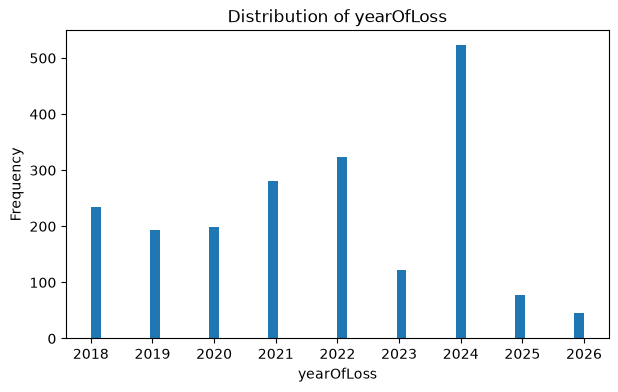

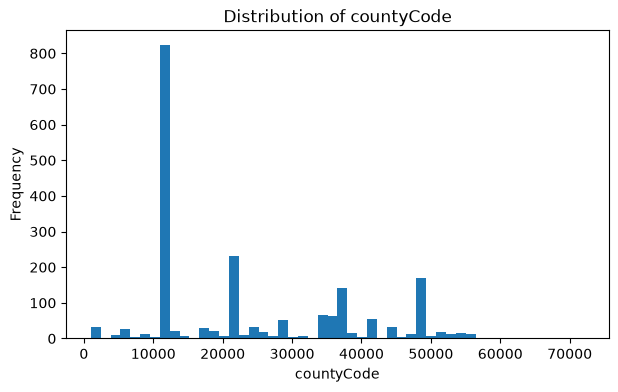

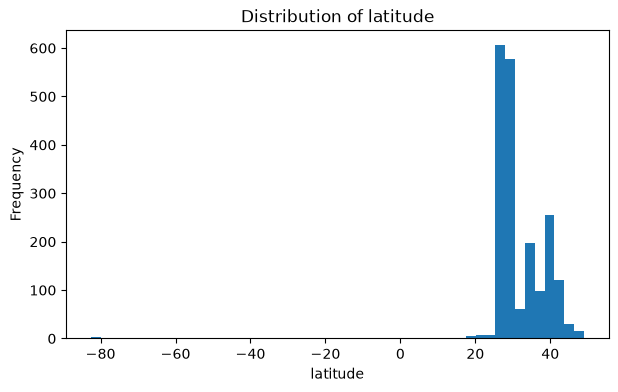

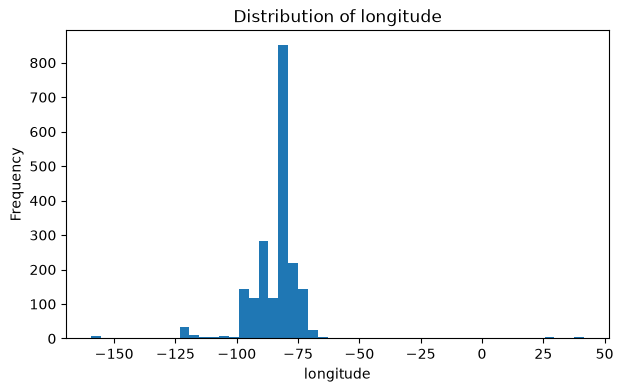

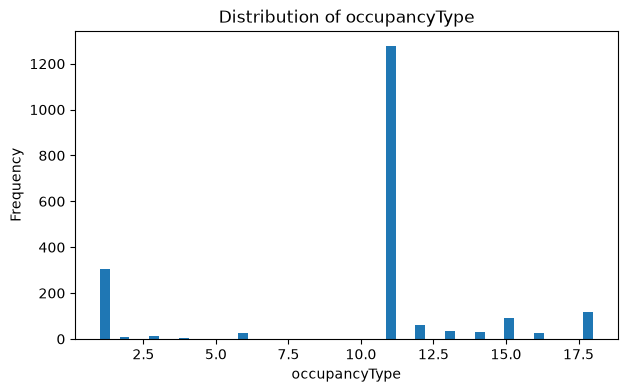

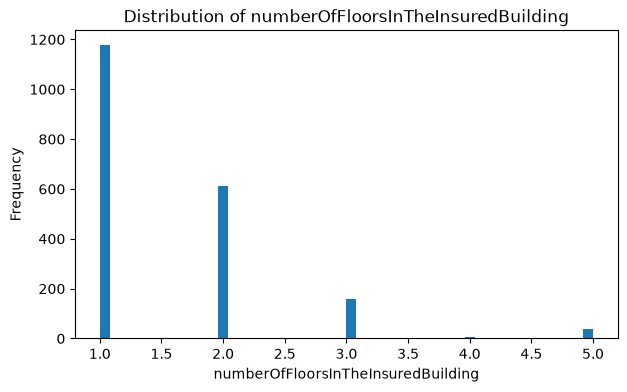

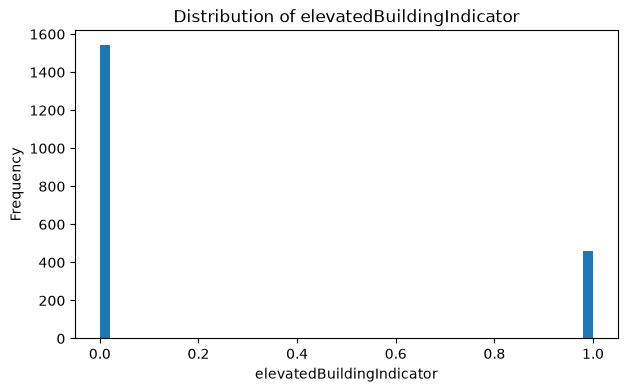

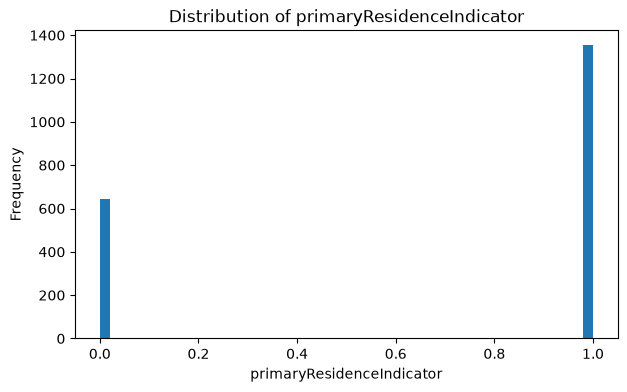

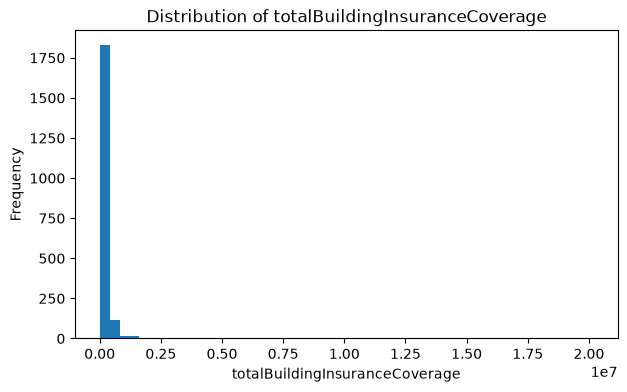

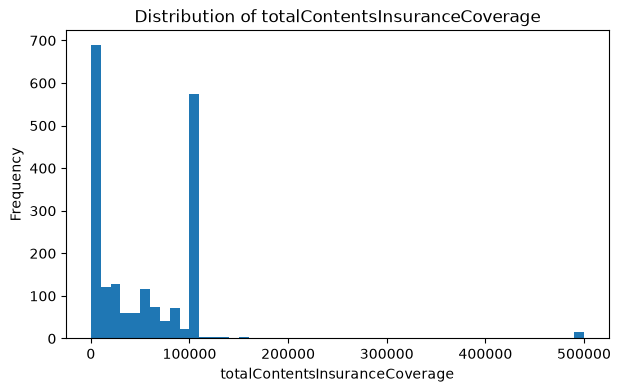

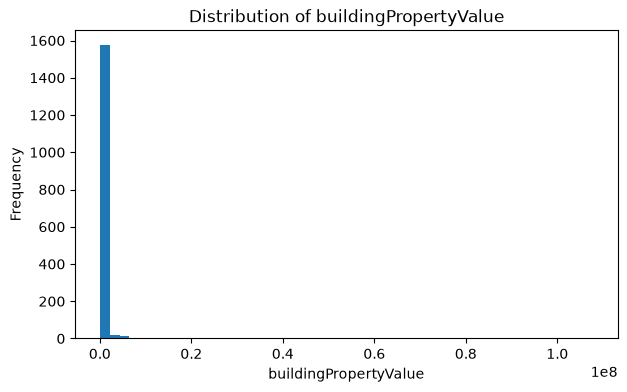

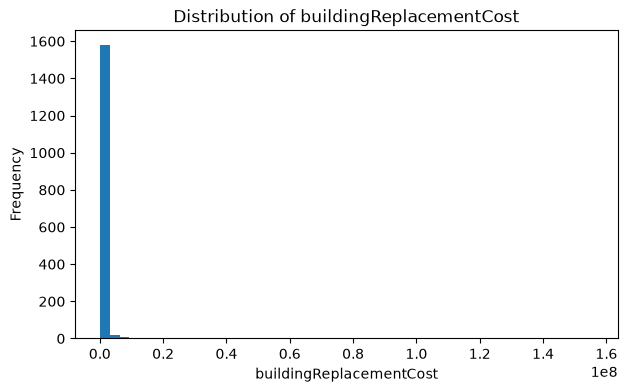

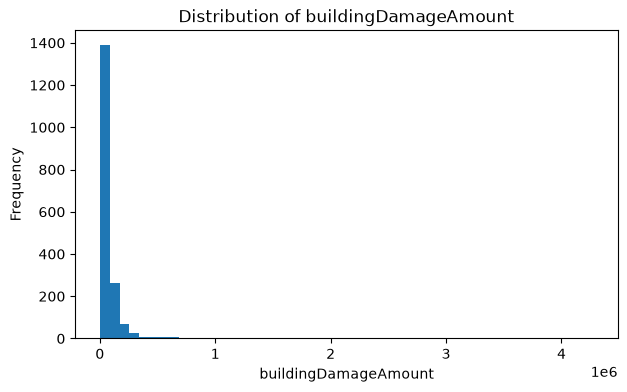

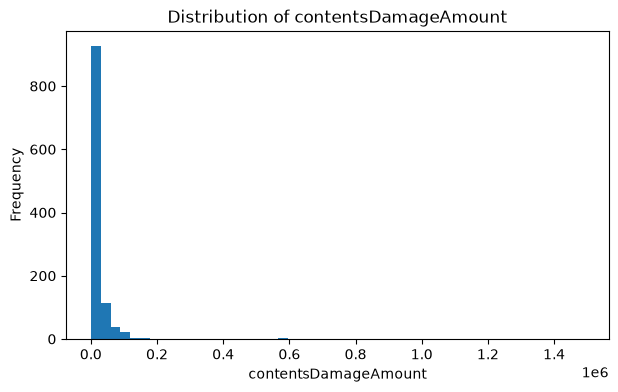

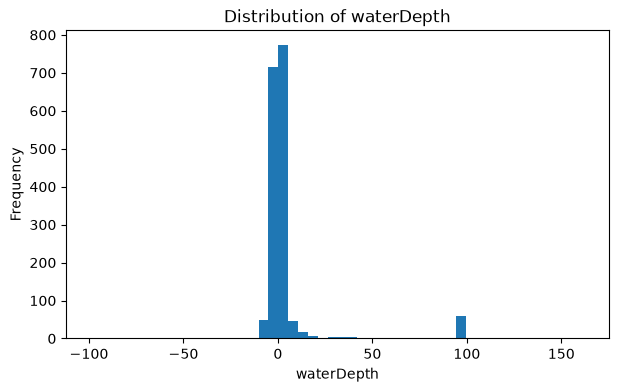

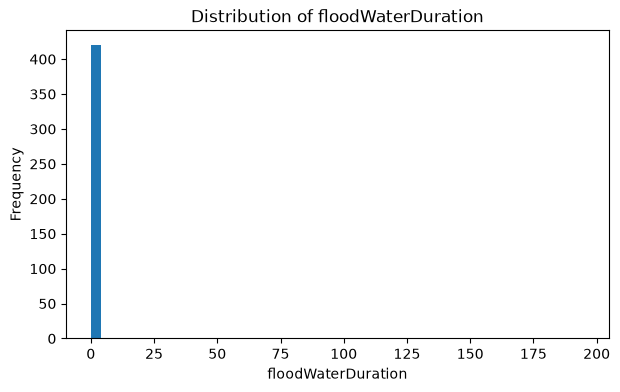

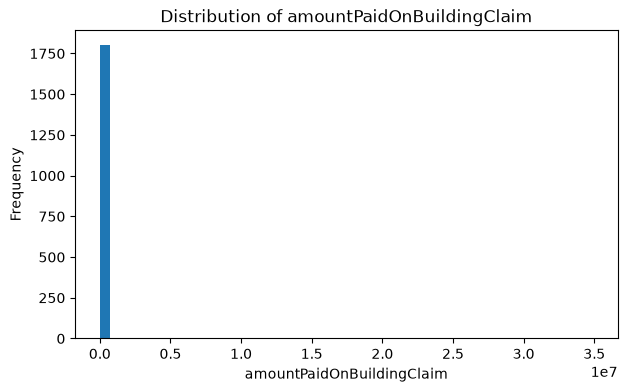

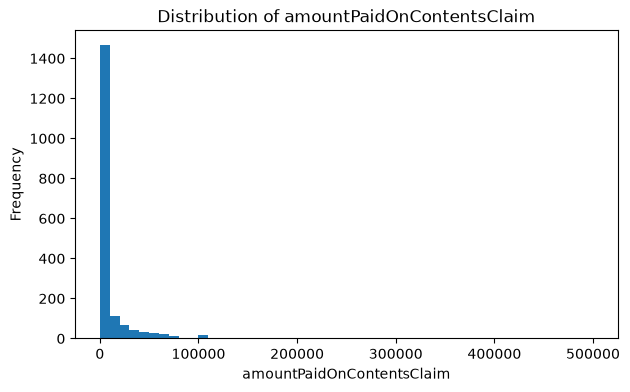

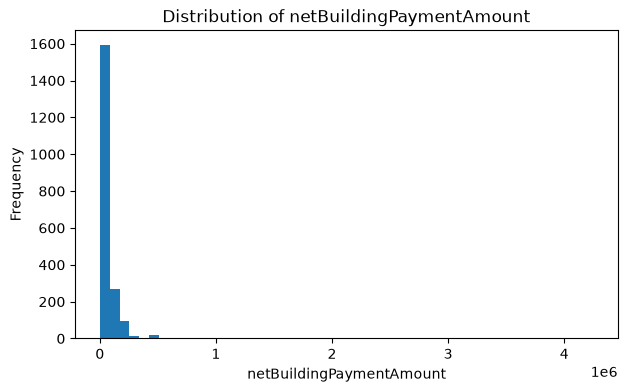

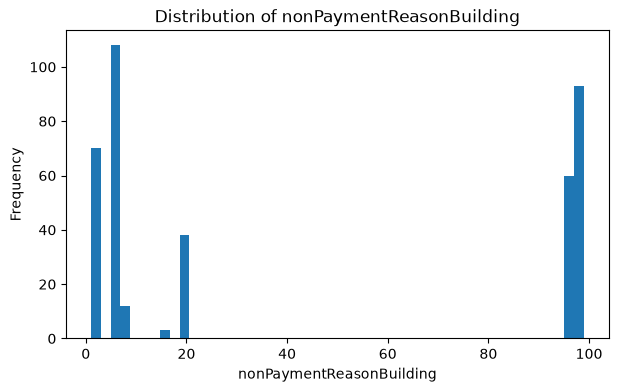

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [11]:
geo_cols = [
    "claim_ref",
    "state",
    "reportedZipCode",
    "countyCode",
    "latitude",
    "longitude"
]

# Suspicious latitude values
print("Suspicious latitude:")
display(
    df[
        (df["latitude"] < 20) |
        (df["latitude"] > 50)
    ][geo_cols].sort_values("latitude")
)

# Suspicious longitude values
print("\nSuspicious longitude:")
display(
    df[
        (df["longitude"] > -65) |
        (df["longitude"] < -130)
    ][geo_cols].sort_values("longitude")
)

Suspicious latitude:


,claim_ref,state,reportedZipCode,countyCode,latitude,longitude
1497,CLM-7710949,FL,33634,12057.0,-82.6,28.0
1539,CLM-6092826,FL,33957,12071.0,-82.2,26.5
1656,CLM-7282771,FL,33917,12071.0,-81.8,26.7
1052,CLM-7576391,OH,45750,39167.0,-81.4,39.4
1521,CLM-5565716,WV,26833,54023.0,-79.2,39.1
1170,CLM-7555820,PR,769,72043.0,18.1,-66.4
808,CLM-7769533,PR,641,NaN,18.3,-66.7
235,CLM-7333444,PR,773,NaN,18.4,-65.7
423,CLM-5843795,PR,969,72061.0,18.4,-66.1
404,CLM-5946009,PR,612,NaN,18.5,-66.7



Suspicious longitude:


,claim_ref,state,reportedZipCode,countyCode,latitude,longitude
693,CLM-6197891,HI,96756,15007.0,21.9,-159.5
153,CLM-5725175,HI,96826,15003.0,21.3,-157.8
695,CLM-5666358,HI,96816,15003.0,21.3,-157.8
300,CLM-5537577,HI,96821,15003.0,21.3,-157.8
1556,CLM-7475341,HI,96821,15003.0,21.3,-157.8
0,CLM-6119947,HI,96734,15003.0,21.4,-157.7
1882,CLM-5841956,HI,96748,15009.0,21.1,-157.0
1539,CLM-6092826,FL,33957,12071.0,-82.2,26.5
1656,CLM-7282771,FL,33917,12071.0,-81.8,26.7
1497,CLM-7710949,FL,33634,12057.0,-82.6,28.0


In [12]:
# Mainland US coordinate sanity check
# HI and PR have different valid geographic ranges, so exclude them.

mainland = ~df["state"].isin(["HI", "PR", "AK"])

suspicious_geo = df[
    mainland & (
        (df["latitude"] < 20) |
        (df["latitude"] > 50) |
        (df["longitude"] > -60) |
        (df["longitude"] < -130)
    )
][[
    "claim_ref",
    "state",
    "reportedZipCode",
    "countyCode",
    "latitude",
    "longitude"
]].sort_values(["state", "claim_ref"])

display(suspicious_geo)
print("Suspicious mainland coordinate records:", len(suspicious_geo))

,claim_ref,state,reportedZipCode,countyCode,latitude,longitude
1539,CLM-6092826,FL,33957,12071.0,-82.2,26.5
1656,CLM-7282771,FL,33917,12071.0,-81.8,26.7
1497,CLM-7710949,FL,33634,12057.0,-82.6,28.0
572,CLM-8100313,IA,50317,19153.0,NaN,41.6
1817,CLM-6284078,LA,70068,22095.0,NaN,30.1
1047,CLM-7961163,LA,70769,22005.0,NaN,30.3
1052,CLM-7576391,OH,45750,39167.0,-81.4,39.4
1521,CLM-5565716,WV,26833,54023.0,-79.2,39.1


Suspicious mainland coordinate records: 8


### Clean 8
8 records with coordinate values that are inconsistent with their state/location

In [13]:
bad_latitude_claims = [
    "CLM-6092826",
    "CLM-7282771",
    "CLM-7710949",
    "CLM-7576391",
    "CLM-5565716"
]

bad_longitude_claims = [
    "CLM-8100313",
    "CLM-6284078",
    "CLM-7961163"
]

df.loc[
    df["claim_ref"].isin(bad_latitude_claims),
    "latitude"
] = np.nan

df.loc[
    df["claim_ref"].isin(bad_longitude_claims),
    "longitude"
] = np.nan

In [14]:
print("Missing latitude:", df["latitude"].isna().sum())
print("Missing longitude:", df["longitude"].isna().sum())

Missing latitude: 22
Missing longitude: 17


In [15]:
outlier_cols = [
    "totalBuildingInsuranceCoverage",
    "totalContentsInsuranceCoverage",
    "buildingPropertyValue",
    "buildingReplacementCost",
    "buildingDamageAmount",
    "contentsDamageAmount",
    "waterDepth",
    "floodWaterDuration",
    "amountPaidOnBuildingClaim",
    "amountPaidOnContentsClaim",
    "netBuildingPaymentAmount"
]

outlier_results = []

for col in outlier_cols:
    s = df[col].dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (s < lower) | (s > upper)

    outlier_results.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_pct": mask.mean() * 100
    })

outlier_results = pd.DataFrame(outlier_results)

outlier_results.sort_values(
    "outlier_pct",
    ascending=False
)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
9,amountPaidOnContentsClaim,0.0000,3895.5550,3895.555,-5843.3325,9738.8875,348,19.247788
0,totalBuildingInsuranceCoverage,170525.0000,250000.0000,79475.000,51312.5000,369212.5000,294,14.700000
6,waterDepth,0.0000,2.0000,2.000,-3.0000,5.0000,225,13.274336
5,contentsDamageAmount,0.0000,16339.0000,16339.000,-24508.5000,40847.5000,130,11.669659
3,buildingReplacementCost,187195.0000,418147.0000,230952.000,-159233.0000,764575.0000,181,11.138462
2,buildingPropertyValue,143427.0000,325147.0000,181720.000,-129153.0000,597727.0000,180,11.076923
8,amountPaidOnBuildingClaim,5264.6125,79652.0225,74387.410,-106316.5025,191233.1375,131,7.237569
10,netBuildingPaymentAmount,2253.3100,69740.0650,67486.755,-98976.8225,170970.1975,138,6.903452
4,buildingDamageAmount,6304.5000,78004.5000,71700.000,-101245.5000,185554.5000,119,6.677890
7,floodWaterDuration,0.0000,0.0000,0.000,0.0000,0.0000,11,2.612827


In [16]:
df[df["floodWaterDuration"] > 0][[
    "claim_ref",
    "state",
    "floodEvent",
    "waterDepth",
    "floodWaterDuration",
    "buildingDamageAmount",
    "source_system"
]].sort_values("floodWaterDuration")

,claim_ref,state,floodEvent,waterDepth,floodWaterDuration,buildingDamageAmount,source_system
513,CLM-5597390,CA,Tropical Storm Hilary,1.0,1.0,107802.0,legacy_bdx
595,CLM-6819541,FL,Hurricane Helene,61.0,1.0,61317.0,core
793,CLM-6151269,FL,Hurricane Milton,40.0,1.0,46079.0,core
1100,CLM-5893488,LA,Hurricane Francine,2.0,1.0,71297.0,core
1235,CLM-6162258,FL,Hurricane Milton,7.0,1.0,23647.0,core
1667,CLM-5479469,FL,Hurricane Ian,5.0,1.0,73353.0,core
1604,CLM-6418207,IL,NaN,8.0,2.0,57066.0,core
953,CLM-6345687,FL,Hurricane Ian,64.0,2.0,164121.0,core
1905,CLM-7376940,IA,June Midwest Flooding,-7.0,2.0,77964.0,core
1612,CLM-5745954,FL,Hurricane Ian,0.0,2.0,86996.0,core


In [17]:
df[df["claim_ref"] == "CLM-8103436"].T

,317
claim_ref,CLM-8103436
source_system,core
dateOfLoss,2019-01-20 00:00:00+00:00
yearOfLoss,2019
state,MS
reportedZipCode,39156
countyCode,28149.0
latitude,32.5
longitude,-90.8
floodEvent,NaN


In [18]:
df["floodWaterDuration"].value_counts().sort_index()

floodWaterDuration
0.0      410
1.0        6
2.0        4
195.0      1
Name: count, dtype: int64

### Outlier
CLM-8103436 is potential outlier as it has 195 as its flood water duration

In [19]:
damage_outliers = df[
    df["buildingDamageAmount"] >
    outlier_results.loc[
        outlier_results["column"] == "buildingDamageAmount",
        "upper_bound"
    ].iloc[0]
]

print("Number of damage outliers:", len(damage_outliers))

display(
    damage_outliers[
        [
            "claim_ref",
            "state",
            "floodEvent",
            "buildingDamageAmount",
            "buildingPropertyValue",
            "buildingReplacementCost",
            "totalBuildingInsuranceCoverage",
            "waterDepth",
            "floodWaterDuration"
        ]
    ].sort_values("buildingDamageAmount", ascending=False)
)

Number of damage outliers: 119


,claim_ref,state,floodEvent,buildingDamageAmount,buildingPropertyValue,buildingReplacementCost,totalBuildingInsuranceCoverage,waterDepth,floodWaterDuration
245,CLM-7337861,FL,Hurricane Helene,4272992.0,8204622.0,9540258.0,10520000.0,2.0,NaN
99,CLM-7080832,FL,Hurricane Ian,3085581.0,8760510.0,10926936.0,13000000.0,8.0,NaN
38,CLM-5804784,FL,Hurricane Ian,1502239.0,4536746.0,5577981.0,4750000.0,3.0,NaN
876,CLM-8156698,FL,Hurricane Helene,1499558.0,2282477.0,2543381.0,2842000.0,5.0,NaN
1649,CLM-5876462,FL,Hurricane Ian,1299746.0,4548666.0,5685832.0,5686000.0,2.0,NaN
...,...,...,...,...,...,...,...,...,...
1527,CLM-7282073,FL,Hurricane Ian,191422.0,390884.0,488605.0,250000.0,1.0,NaN
1276,CLM-6033144,FL,Hurricane Ian,190514.0,368824.0,392365.0,250000.0,0.0,NaN
764,CLM-7804614,FL,Hurricane Ian,190251.0,356611.0,395588.0,250000.0,0.0,NaN
1914,CLM-6223766,FL,Hurricane Helene,189109.0,631775.0,796699.0,250000.0,3.0,NaN


In [20]:
low_damage = df[
    df["buildingDamageAmount"].notna() &
    (df["buildingDamageAmount"] <= 1000)
]

print("Claims with damage <= $1,000:", len(low_damage))

display(
    low_damage[[
        "claim_ref",
        "state",
        "floodEvent",
        "buildingDamageAmount",
        "buildingPropertyValue",
        "buildingReplacementCost",
        "totalBuildingInsuranceCoverage",
        "waterDepth",
        "floodWaterDuration",
        "amountPaidOnBuildingClaim",
        "netBuildingPaymentAmount"
    ]].sort_values("buildingDamageAmount")
)

Claims with damage <= $1,000: 198


,claim_ref,state,floodEvent,buildingDamageAmount,buildingPropertyValue,buildingReplacementCost,totalBuildingInsuranceCoverage,waterDepth,floodWaterDuration,amountPaidOnBuildingClaim,netBuildingPaymentAmount
1,CLM-5642877,MA,Hurricane Ida,0.0,NaN,NaN,250000.0,NaN,NaN,0.0,0.0
14,CLM-5576313,WA,NaN,0.0,NaN,NaN,250000.0,0.0,NaN,NaN,0.0
15,CLM-7455343,LA,Hurricane Ida,0.0,132438.0,228342.0,195000.0,0.0,NaN,0.0,0.0
20,CLM-6223381,OH,NaN,0.0,293000.0,329700.0,19000.0,NaN,NaN,0.0,0.0
23,CLM-7806166,FL,Hurricane Ian,0.0,311295.0,371882.0,250000.0,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
683,CLM-6262285,LA,Hurricane Ida,855.0,96771.0,153429.0,138000.0,NaN,NaN,822.0,822.0
1719,CLM-7850935,CA,NaN,929.0,255361.0,283734.0,250000.0,0.0,0.0,NaN,0.0
1873,CLM-7392568,NC,Hurricane Florence,934.0,130999.0,16374838.0,250000.0,2.0,0.0,NaN,0.0
107,CLM-7218663,NC,NaN,944.0,212061.0,459583.0,250000.0,-3.0,NaN,NaN,0.0


In [21]:
suspicious_payment = df[
    (df["buildingDamageAmount"] > 0) &
    (df["buildingDamageAmount"] <= 1000) &
    (df["amountPaidOnBuildingClaim"] > 10000)
]

print("Suspicious low-damage/high-payment claims:", len(suspicious_payment))

display(
    suspicious_payment[[
        "claim_ref",
        "state",
        "floodEvent",
        "buildingDamageAmount",
        "amountPaidOnBuildingClaim",
        "netBuildingPaymentAmount",
        "totalBuildingInsuranceCoverage",
        "buildingPropertyValue",
        "buildingReplacementCost"
    ]].sort_values(
        "amountPaidOnBuildingClaim",
        ascending=False
    )
)

Suspicious low-damage/high-payment claims: 9


,claim_ref,state,floodEvent,buildingDamageAmount,amountPaidOnBuildingClaim,netBuildingPaymentAmount,totalBuildingInsuranceCoverage,buildingPropertyValue,buildingReplacementCost
1474,CLM-5470901,FL,Hurricane Ian,1.0,156000.00,156000.00,156000.0,NaN,NaN
655,CLM-5632217,FL,Hurricane Helene,1.0,140521.19,140521.19,250000.0,NaN,NaN
1484,CLM-7270798,FL,Hurricane Ian,1.0,122788.33,122788.33,250000.0,NaN,NaN
666,CLM-6900261,AR,NaN,1.0,121342.48,121342.48,250000.0,NaN,NaN
691,CLM-7032381,FL,Hurricane Ian,1.0,92289.46,92289.46,163000.0,NaN,NaN
1645,CLM-8087807,FL,Hurricane Ian,1.0,49675.74,49675.74,250000.0,NaN,NaN
305,CLM-5868777,FL,Hurricane Ian,1.0,33192.01,33192.01,100000.0,NaN,NaN
297,CLM-7330184,FL,Hurricane Ian,1.0,14084.08,14084.08,250000.0,NaN,NaN
1656,CLM-7282771,FL,Hurricane Ian,1.0,10652.24,10652.24,250000.0,NaN,NaN


In [22]:
relationship_issues = df[
    (
        (df["buildingDamageAmount"] > df["buildingPropertyValue"]) |
        (df["buildingDamageAmount"] > df["buildingReplacementCost"])
    )
][[
    "claim_ref",
    "state",
    "floodEvent",
    "buildingDamageAmount",
    "buildingPropertyValue",
    "buildingReplacementCost",
    "totalBuildingInsuranceCoverage"
]].copy()

print("Records with damage > property OR replacement:",
      len(relationship_issues))

display(
    relationship_issues
    .sort_values("buildingDamageAmount", ascending=False)
    .head(30)
)

Records with damage > property OR replacement: 6


,claim_ref,state,floodEvent,buildingDamageAmount,buildingPropertyValue,buildingReplacementCost,totalBuildingInsuranceCoverage
929,CLM-7185471,MO,Late July Flooding,1088937.0,213573.0,255329.0,250000.0
1563,CLM-5459928,FL,Hurricane Ian,354174.0,348244.0,404935.0,500000.0
10,CLM-6726350,FL,Hurricane Helene,199577.0,180686.0,358376.0,250000.0
439,CLM-6788159,WA,NaN,163666.0,148000.0,223050.0,165000.0
1199,CLM-6929169,KY,Late July Flooding,78213.0,67642.0,220183.0,141000.0
1127,CLM-8150954,FL,Hurricane Helene,23772.0,21772.0,38546.0,66000.0


In [23]:
payment_coverage_issues = df[
    df["amountPaidOnBuildingClaim"] >
    df["totalBuildingInsuranceCoverage"]
][[
    "claim_ref",
    "state",
    "floodEvent",
    "amountPaidOnBuildingClaim",
    "netBuildingPaymentAmount",
    "totalBuildingInsuranceCoverage",
    "buildingDamageAmount"
]].sort_values(
    "amountPaidOnBuildingClaim",
    ascending=False
)

print("Payment > coverage:", len(payment_coverage_issues))

display(payment_coverage_issues)

Payment > coverage: 21


,claim_ref,state,floodEvent,amountPaidOnBuildingClaim,netBuildingPaymentAmount,totalBuildingInsuranceCoverage,buildingDamageAmount
174,CLM-5544627,FL,Hurricane Helene,34912215.45,44586.42,15000000.0,45824.0
1266,CLM-6925211,FL,Hurricane Helene,950091.17,2423.80,500000.0,3674.0
135,CLM-5685223,FL,Hurricane Helene,601320.57,94471.19,250000.0,99471.0
1526,CLM-8078474,IL,NaN,501394.56,7124.44,199000.0,15623.0
517,CLM-6028898,FL,Hurricane Ian,498978.44,250000.00,250000.0,248856.0
1090,CLM-5988109,TX,Tropical Storm Imelda,494190.20,85213.31,200000.0,83439.0
538,CLM-6292038,KY,Late July Flooding,490633.32,5821.32,167000.0,13721.0
716,CLM-6887750,TX,NaN,481263.76,0.00,250000.0,NaN
474,CLM-5471799,SC,NaN,471108.86,55251.15,250000.0,53180.0
1217,CLM-7798283,FL,NaN,417022.49,0.00,250000.0,0.0


In [24]:
display(
    df[df["claim_ref"] == "CLM-5544627"].T
)

,174
claim_ref,CLM-5544627
source_system,core
dateOfLoss,2024-09-26 00:00:00+00:00
yearOfLoss,2024
state,FL
reportedZipCode,33931
countyCode,12071.0
latitude,26.4
longitude,-81.9
floodEvent,Hurricane Helene


#### Gross building payment anomalies: Several records contain gross building payment amounts substantially exceeding coverage and/or damage. Because the corresponding net payment amounts are often materially lower, these were treated as potentially accounting-related rather than definitively erroneous and were retained. Payment fields were excluded from the damage prediction model to avoid leakage.

In [25]:
high_missing_cols = [
    "nonPaymentReasonBuilding",
    "floodWaterDuration",
    "contentsDamageAmount",
    "floodEvent",
    "buildingPropertyValue",
    "buildingReplacementCost",
    "waterDepth"
]

for col in high_missing_cols:
    print(f"\n--- {col} ---")
    
    result = df.groupby(
        df[col].isna()
    )["buildingDamageAmount"].agg(
        ["count", "mean", "median"]
    )
    
    print(result)


--- nonPaymentReasonBuilding ---
                          count          mean   median
nonPaymentReasonBuilding                              
False                       213   1585.136150      0.0
True                       1569  72022.604844  33261.0

--- floodWaterDuration ---
                    count          mean   median
floodWaterDuration                              
False                 361  41387.451524  15868.0
True                 1421  69247.171710  24981.0

--- contentsDamageAmount ---
                      count          mean   median
contentsDamageAmount                              
False                  1109  59313.373309  29519.0
True                    673  70672.466568  17060.0

--- floodEvent ---
            count          mean   median
floodEvent                              
False        1337  76481.411369  35714.0
True          445  24911.132584   8850.0

--- buildingPropertyValue ---
                       count          mean   median
buildingPropertyValue

In [26]:
categorical_cols = [
    "source_system",
    "state",
    "reportedZipCode",
    "floodEvent",
    "causeOfDamage",
    "ratedFloodZone",
    "occupancyType",
    "elevatedBuildingIndicator",
    "primaryResidenceIndicator"
]

cat_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "missing": df[categorical_cols].isna().sum(),
    "missing_pct": df[categorical_cols].isna().mean() * 100
}).sort_values("unique_values", ascending=False)

cat_summary

,unique_values,missing,missing_pct
reportedZipCode,1047,0,0.00
floodEvent,62,551,27.55
state,47,0,0.00
ratedFloodZone,27,5,0.25
occupancyType,12,0,0.00
causeOfDamage,6,27,1.35
source_system,2,0,0.00
elevatedBuildingIndicator,2,0,0.00
primaryResidenceIndicator,2,0,0.00


In [27]:
zip_counts = df["reportedZipCode"].value_counts()

print("Total ZIP codes:", len(zip_counts))
print("ZIP codes appearing once:", (zip_counts == 1).sum())
print("ZIP codes appearing <= 2 times:", (zip_counts <= 2).sum())
print("ZIP codes appearing <= 5 times:", (zip_counts <= 5).sum())

print("\nFrequency distribution:")
print(zip_counts.describe())

print("\nMost common ZIP codes:")
print(zip_counts.head(20))

Total ZIP codes: 1047
ZIP codes appearing once: 752
ZIP codes appearing <= 2 times: 900
ZIP codes appearing <= 5 times: 995

Frequency distribution:
count    1047.000000
mean        1.910220
std         2.816498
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        39.000000
Name: count, dtype: float64

Most common ZIP codes:
reportedZipCode
33908    39
33957    35
70068    27
33706    25
33708    22
33931    20
34223    18
34102    18
33904    15
33703    15
34652    14
34217    13
33917    12
34224    11
33702    11
33315    11
33615    11
28560    11
34103    11
33950    10
Name: count, dtype: int64


In [28]:
# Columns that we decided not to use for ML
df_clean = pd.read_csv("nfip_claims_cleaned.csv")

# print(df_clean.shape)
# df_clean.head()

drop_cols = [
    "claim_ref",
    "reportedZipCode",
    "amountPaidOnBuildingClaim",
    "amountPaidOnContentsClaim",
    "netBuildingPaymentAmount",
    "mostRecentPaymentDate",
    "nonPaymentReasonBuilding",
    "contentsDamageAmount",
    "openDate",
    'source_system'
]

df_model = df_clean.drop(columns=drop_cols).copy()

# Create a separate dataframe for modeling
df_model = df_clean.drop(columns=drop_cols).copy()

print("Original cleaned data:", df_clean.shape)
print("Modeling data:", df_model.shape)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Original cleaned data: (2000, 31)
Modeling data: (2000, 21)

Remaining columns:
['dateOfLoss', 'yearOfLoss', 'state', 'countyCode', 'latitude', 'longitude', 'floodEvent', 'causeOfDamage', 'ratedFloodZone', 'occupancyType', 'numberOfFloorsInTheInsuredBuilding', 'originalConstructionDate', 'elevatedBuildingIndicator', 'primaryResidenceIndicator', 'totalBuildingInsuranceCoverage', 'totalContentsInsuranceCoverage', 'buildingPropertyValue', 'buildingReplacementCost', 'buildingDamageAmount', 'waterDepth', 'floodWaterDuration']


In [29]:
target = "buildingDamageAmount"

print("Target:", target)
print("Target missing:", df_model[target].isna().sum())

Target: buildingDamageAmount
Target missing: 218


In [30]:
X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 20)
y shape: (2000,)


### We give it information that is easier for the model to use:
loss_month = 9

building_age = 39


In [31]:
# Convert date columns to datetime
df_model["dateOfLoss"] = pd.to_datetime(df_model["dateOfLoss"], errors="coerce")
df_model["originalConstructionDate"] = pd.to_datetime(
    df_model["originalConstructionDate"], errors="coerce"
)

# Create useful date features
df_model["loss_month"] = df_model["dateOfLoss"].dt.month

# Building age when the loss occurred
df_model["building_age"] = (
    df_model["dateOfLoss"].dt.year -
    df_model["originalConstructionDate"].dt.year
)

# Drop the original date columns
df_model = df_model.drop(
    columns=["dateOfLoss", "originalConstructionDate"]
)

print(df_model.columns.tolist())

['yearOfLoss', 'state', 'countyCode', 'latitude', 'longitude', 'floodEvent', 'causeOfDamage', 'ratedFloodZone', 'occupancyType', 'numberOfFloorsInTheInsuredBuilding', 'elevatedBuildingIndicator', 'primaryResidenceIndicator', 'totalBuildingInsuranceCoverage', 'totalContentsInsuranceCoverage', 'buildingPropertyValue', 'buildingReplacementCost', 'buildingDamageAmount', 'waterDepth', 'floodWaterDuration', 'loss_month', 'building_age']


In [32]:
# Remove rows where target is missing
df_model = df_model.dropna(subset=["buildingDamageAmount"]).copy()

print("Shape after removing missing target:", df_model.shape)
print("Missing target:", df_model["buildingDamageAmount"].isna().sum())

Shape after removing missing target: (1782, 21)
Missing target: 0


In [33]:
# Separate target
target = "buildingDamageAmount"

X = df_model.drop(columns=[target])
y = df_model[target]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

print("\nNumber of categorical:", len(categorical_cols))
print("Number of numerical:", len(numerical_cols))

Categorical columns:
['state', 'floodEvent', 'causeOfDamage', 'ratedFloodZone']

Numerical columns:
['yearOfLoss', 'countyCode', 'latitude', 'longitude', 'occupancyType', 'numberOfFloorsInTheInsuredBuilding', 'elevatedBuildingIndicator', 'primaryResidenceIndicator', 'totalBuildingInsuranceCoverage', 'totalContentsInsuranceCoverage', 'buildingPropertyValue', 'buildingReplacementCost', 'waterDepth', 'floodWaterDuration', 'building_age']

Number of categorical: 4
Number of numerical: 15


C:\Users\SIDDESHWAR\AppData\Local\Temp\ipykernel_29300\1108371344.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [34]:
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

floodWaterDuration                    1421
floodEvent                             445
waterDepth                             274
buildingPropertyValue                  157
buildingReplacementCost                157
building_age                            23
causeOfDamage                           18
latitude                                17
longitude                               14
numberOfFloorsInTheInsuredBuilding      10
countyCode                               8
ratedFloodZone                           5
dtype: int64


In [44]:
%pip install scikit-learn
%pip install scikit-learn scipy matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 2.1 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.3 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.3 MB 1.9 MB/s eta 0:00:04
   ------------- -------------------------- 2.9/8.3 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.3 MB 2.2 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.3 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.3 MB 2.5 MB/s eta 0:00:02
   ----------------------------- ---------- 6.0/8.3 MB 2.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 2.9 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical features:
# NaN -> median + missing indicator
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    ))
])

# Categorical features:
# NaN -> "Missing" -> one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [50]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_model.drop(columns=["buildingDamageAmount"])
y = df_model["buildingDamageAmount"]

# Create bins for the skewed regression target
bins = [-1, 10000, 50000, 100000, 500000, float("inf")]

y_bins = pd.cut(
    y,
    bins=bins,
    labels=False
)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1425, 20)
X_test: (357, 20)
y_train: (1425,)
y_test: (357,)


In [37]:
X_train.head()

,yearOfLoss,state,countyCode,latitude,longitude,floodEvent,causeOfDamage,ratedFloodZone,occupancyType,numberOfFloorsInTheInsuredBuilding,elevatedBuildingIndicator,primaryResidenceIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,buildingPropertyValue,buildingReplacementCost,waterDepth,floodWaterDuration,loss_month,building_age
201,2021,LA,22103.0,30.5,-90.1,Hurricane Ida,4,A11,18,1.0,0,0,60000.0,0.0,32790.0,50446.0,0.0,NaN,8,51.0
703,2021,LA,22019.0,30.2,-93.2,2021 Mid-Spring Severe Storms,4,X,1,1.0,0,0,75000.0,30000.0,90764.0,97108.0,0.0,NaN,5,2.0
1244,2023,FL,12101.0,28.4,-82.7,Hurricane Idalia,1,AE,11,1.0,0,1,121000.0,0.0,125459.0,150027.0,1.0,NaN,8,49.0
1952,2020,TX,48215.0,26.2,-98.0,Hurricane Hanna,4,X,11,1.0,0,1,125000.0,50000.0,140883.0,176104.0,1.0,NaN,7,10.0
1145,2022,FL,12015.0,26.9,-82.2,Hurricane Ian,4,AE,11,1.0,0,0,237000.0,74000.0,136885.0,181890.0,1.0,NaN,9,43.0


In [51]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train:", X_train_processed.shape)
print("Processed test:", X_test_processed.shape)

Processed train: (1425, 160)
Processed test: (357, 160)


In [52]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

# Baseline model: always predicts the training median
baseline = DummyRegressor(strategy="median")

baseline.fit(X_train_processed, y_train)

# Predict on test set
y_pred_baseline = baseline.predict(X_test_processed)

# Evaluate
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 51462.73669467787


In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Baseline MAE:", baseline_mae)
print("Improvement:", baseline_mae - rf_mae)
print(
    "Improvement %:",
    ((baseline_mae - rf_mae) / baseline_mae) * 100
)

Random Forest MAE: 47147.80040348146
Baseline MAE: 51462.73669467787
Improvement: 4314.936291196413
Improvement %: 8.384583814103012


In [54]:
print(y_train.describe())

print("\nTarget quantiles:")
print(y_train.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

count    1.425000e+03
mean     6.473387e+04
std      1.759128e+05
min      0.000000e+00
25%      6.249000e+03
50%      2.337200e+04
75%      7.811000e+04
max      4.272992e+06
Name: buildingDamageAmount, dtype: float64

Target quantiles:
0.25      6249.00
0.50     23372.00
0.75     78110.00
0.90    142571.60
0.95    219223.60
0.99    521465.72
Name: buildingDamageAmount, dtype: float64


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Log-transform target
y_train_log = np.log1p(y_train)

# Train model
rf_log = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train_processed, y_train_log)

# Predict in log space
y_pred_log = rf_log.predict(X_test_processed)

# Convert predictions back to dollars
y_pred_log_dollars = np.expm1(y_pred_log)

# Evaluate in original dollar scale
rf_log_mae = mean_absolute_error(y_test, y_pred_log_dollars)

print("Log-transformed RF MAE:", rf_log_mae)
print("Median baseline MAE:", baseline_mae)
print("Improvement:", baseline_mae - rf_log_mae)
print(
    "Improvement %:",
    ((baseline_mae - rf_log_mae) / baseline_mae) * 100
)

Log-transformed RF MAE: 31,197.299372668
Median baseline MAE: 51,462.736694678
Improvement: 20,265.437322760
Improvement %: 39.337678175%


In [56]:
# Compare actual vs predicted values
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_log_dollars
})

# Look at the largest actual claims
comparison["error"] = comparison["predicted"] - comparison["actual"]
comparison["absolute_error"] = comparison["error"].abs()

print("Largest actual claims:")
print(
    comparison
    .sort_values("actual", ascending=False)
    .head(10)
    .to_string(index=False)
)

Largest actual claims:
  actual     predicted          error  absolute_error
926112.0 318746.142841 -607365.857159   607365.857159
681542.0 127905.278389 -553636.721611   553636.721611
591327.0 176022.019642 -415304.980358   415304.980358
520194.0  96029.571173 -424164.428827   424164.428827
507406.0  23032.638721 -484373.361279   484373.361279
463351.0 102170.151179 -361180.848821   361180.848821
374522.0 299491.130060  -75030.869940    75030.869940
315981.0 215338.267606 -100642.732394   100642.732394
308461.0 163581.197116 -144879.802884   144879.802884
305274.0  33304.296625 -271969.703375   271969.703375


In [57]:
# Create claim-size groups based on actual damage
comparison["actual_group"] = pd.cut(
    comparison["actual"],
    bins=[-1, 10000, 50000, 100000, 500000, np.inf],
    labels=[
        "<$10K",
        "$10K-$50K",
        "$50K-$100K",
        "$100K-$500K",
        ">$500K"
    ]
)

group_results = comparison.groupby(
    "actual_group",
    observed=True
).agg(
    count=("actual", "size"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    MAE=("absolute_error", "mean")
)

print(group_results)

              count    actual_mean  predicted_mean            MAE
actual_group                                                     
<$10K           119    3497.277311    12768.409912    9780.288242
$10K-$50K       111   24542.126126    27757.080871   18348.192988
$50K-$100K       64   73907.265625    40345.543555   37134.290081
$100K-$500K      58  172385.086207    89022.008258   96111.935158
>$500K            5  645316.200000   148347.130153  496969.069847


In [58]:
# Relative error for non-zero actual claims
nonzero = comparison["actual"] > 0

comparison["percentage_error"] = (
    comparison.loc[nonzero, "absolute_error"] /
    comparison.loc[nonzero, "actual"]
) * 100

print(
    "Median Absolute Percentage Error:",
    comparison.loc[nonzero, "percentage_error"].median()
)

print(
    "Mean Absolute Percentage Error:",
    comparison.loc[nonzero, "percentage_error"].mean()
)

Median Absolute Percentage Error: 63.85122105933451
Mean Absolute Percentage Error: 2447.9421896777244


In [59]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Random Forest feature importance
importances = rf_log.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance.head(20).to_string(index=False))

                                      feature  importance
                         cat__causeOfDamage_0    0.157462
  num__missingindicator_buildingPropertyValue    0.144248
                              num__waterDepth    0.107385
num__missingindicator_buildingReplacementCost    0.092061
             num__missingindicator_waterDepth    0.082919
                              num__yearOfLoss    0.069633
                   num__buildingPropertyValue    0.044505
                            num__building_age    0.037789
                                num__latitude    0.035505
                 num__buildingReplacementCost    0.027460
          num__totalBuildingInsuranceCoverage    0.022796
          num__totalContentsInsuranceCoverage    0.022094
                               num__longitude    0.022046
                              num__countyCode    0.021492
               num__elevatedBuildingIndicator    0.017330
                   cat__causeOfDamage_Missing    0.016004
              

In [ ]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_mae = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    # Fit preprocessing ONLY on this fold's training data
    preprocessor_cv = clone(preprocessor)

    X_train_processed_cv = preprocessor_cv.fit_transform(X_train_cv)
    X_val_processed_cv = preprocessor_cv.transform(X_val_cv)

    # Log-transform target
    y_train_log_cv = np.log1p(y_train_cv)

    # Model
    rf_cv = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(X_train_processed_cv, y_train_log_cv)

    # Predict and convert back to dollars
    y_pred_cv = np.expm1(
        rf_cv.predict(X_val_processed_cv)
    )

    # MAE in original dollar scale
    mae = mean_absolute_error(y_val_cv, y_pred_cv)

    cv_mae.append(mae)

    print(f"Fold {fold} MAE: ${mae:,.2f}")

print("\n5-Fold CV Results")
print("------------------")
print(f"Mean MAE:   ${np.mean(cv_mae):,.2f}")
print(f"Std MAE:    ${np.std(cv_mae):,.2f}")
print(f"Min MAE:    ${np.min(cv_mae):,.2f}")
print(f"Max MAE:    ${np.max(cv_mae):,.2f}")


Fold 1 MAE: $38,873.52
Fold 2 MAE: $41,204.17
Fold 3 MAE: $31,088.52
Fold 4 MAE: $32,245.91
Fold 5 MAE: $52,541.25

5-Fold CV Results
------------------
Mean MAE:   $35,991.67
Std MAE:    $7,777.08
Min MAE:    $31,088.52
Max MAE:    $52,541.25


In [61]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_log.feature_importances_
})

importance_df["original_feature"] = (
    importance_df["feature"]
    .str.replace(r"^num__", "", regex=True)
    .str.replace(r"^cat__", "", regex=True)
    .str.split("_")
    .str[0]
)

grouped_importance = (
    importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print(grouped_importance)

original_feature
missingindicator                      0.323798
causeOfDamage                         0.187625
waterDepth                            0.107385
yearOfLoss                            0.069633
buildingPropertyValue                 0.044505
building                              0.037789
latitude                              0.035505
buildingReplacementCost               0.027460
totalBuildingInsuranceCoverage        0.022796
totalContentsInsuranceCoverage        0.022094
longitude                             0.022046
floodEvent                            0.021531
countyCode                            0.021492
elevatedBuildingIndicator             0.017330
ratedFloodZone                        0.014610
state                                 0.008185
occupancyType                         0.007372
numberOfFloorsInTheInsuredBuilding    0.006230
primaryResidenceIndicator             0.002615
floodWaterDuration                    0.000000
Name: importance, dtype: float64


In [48]:
import joblib

joblib.dump(rf_log, "nfip_rf_model.pkl")
joblib.dump(preprocessor, "nfip_preprocessor.pkl")

print("Model and preprocessor saved.")

Model and preprocessor saved.


In [62]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Log-transform target
y_train_log = np.log1p(y_train)

# Train HistGradientBoosting
hgb_log = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=10,
    l2_regularization=1.0,
    random_state=42
)

hgb_log.fit(X_train_processed, y_train_log)

# Predict in log space
y_pred_log = hgb_log.predict(X_test_processed)

# Convert back to original dollar scale
y_pred_hgb = np.expm1(y_pred_log)

# MAE
hgb_mae = mean_absolute_error(y_test, y_pred_hgb)

print(f"Log Gradient Boosting MAE: ${hgb_mae:,.2f}")

Log Gradient Boosting MAE: $41,907.56


In [ ]:
print("\nModel Comparison")
print("---------------------------")
print(f"Median Baseline:       ${baseline_mae:,.2f}")
print(f"Random Forest:         ${rf_mae:,.2f}")
# print(f"Log Random Forest:     ${log_rf_mae:,.2f}")
print(f"Log Gradient Boosting: ${hgb_mae:,.2f}")


Model Comparison
---------------------------
Median Baseline:       $51,462.74
Random Forest:         $47,147.80
Log Gradient Boosting: $41,907.56


: 